In [3]:
# 폴더구조를 생성할꺼구요
# 고양이, 멍멍이 이미지 각 폴더로 복사
import os, shutil

original_dataset_dir = './cat_dog/train'

base_dir = 'cat_dog_full'
os.mkdir(base_dir)

train_dir = os.path.join(base_dir,'train')  # cat_dog_full/train
os.mkdir(train_dir)
validation_dir = os.path.join(base_dir,'validation')  # cat_dog_full/validation
os.mkdir(validation_dir)
test_dir = os.path.join(base_dir,'test')  # cat_dog_full/test
os.mkdir(test_dir)

train_cats_dir = os.path.join(train_dir,'cats')  # cat_dog_full/train/cats
os.mkdir(train_cats_dir)
train_dogs_dir = os.path.join(train_dir,'dogs')  # cat_dog_full/train/dogs
os.mkdir(train_dogs_dir)

validation_cats_dir = os.path.join(validation_dir,'cats')  
os.mkdir(validation_cats_dir)
validation_dogs_dir = os.path.join(validation_dir,'dogs')  
os.mkdir(validation_dogs_dir)

test_cats_dir = os.path.join(test_dir,'cats')  
os.mkdir(test_cats_dir)
test_dogs_dir = os.path.join(test_dir,'dogs')  
os.mkdir(test_dogs_dir)


In [5]:
# 폴더 구성이 다 됬으면 이제 파일을 복사해야 해요!
# 고양이와 멍멍이 각각 12,500개의 이미지
# train : 각각 7,000개 사용. 총 14,000개의 이미지 사용
# validation : 각각 3,000개 사용. 총 6,000개의 이미지 사용
# test : 각각 2,500개 사용. 총 5,000개의 이미지 사용

fnames = ['cat.{}.jpg'.format(i) for i in range(7000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(train_cats_dir,fname)
    shutil.copyfile(src, dst)

fnames = ['cat.{}.jpg'.format(i) for i in range(7000,10000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(validation_cats_dir,fname)
    shutil.copyfile(src, dst)

fnames = ['cat.{}.jpg'.format(i) for i in range(10000,12500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(test_cats_dir,fname)
    shutil.copyfile(src, dst)


fnames = ['dog.{}.jpg'.format(i) for i in range(7000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(train_dogs_dir,fname)
    shutil.copyfile(src, dst)

fnames = ['dog.{}.jpg'.format(i) for i in range(7000,10000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(validation_dogs_dir,fname)
    shutil.copyfile(src, dst)

fnames = ['dog.{}.jpg'.format(i) for i in range(10000,12500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(test_dogs_dir,fname)
    shutil.copyfile(src, dst)

Found 14000 images belonging to 2 classes.
Found 6000 images belonging to 2 classes.
x_data의 shape : (20, 150, 150, 3)
t_data의 shape : (20,)
[1. 1. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 0.]


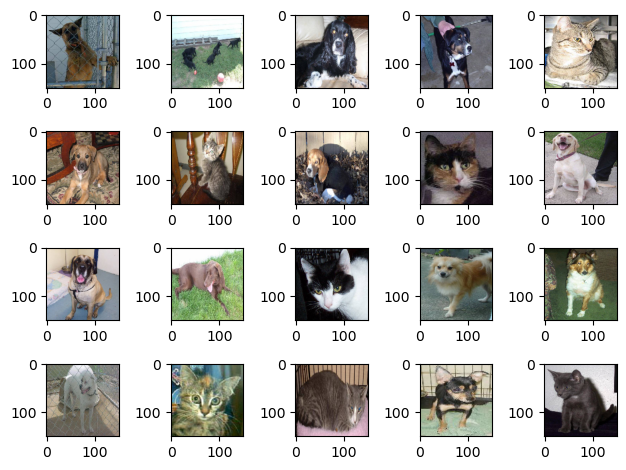

In [1]:
# ImageDataGenerator를 생성해서 사용해 보아요!

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_dir = 'C:/data/cat_dog_full/train'
validation_dir = 'C:/data/cat_dog_full/validation'

# ImageDataGenerator생성
train_datagen = ImageDataGenerator(rescale=1/255)
validation_datagen = ImageDataGenerator(rescale=1/255)

# ImageDataGenerator설정
train_generator = train_datagen.flow_from_directory(
    train_dir,    # target directory
    classes=['cats', 'dogs'],  # cats, dogs 순서로 label을 0, 1로 사용
    target_size=(150,150),     # Image에 대한 size 변경
    batch_size=20,       # 한번에 20개의 이미지에 대한 pixel 정보를 가져와요!
                         # label에 상관없이 가져와요!
    class_mode='binary'  # 이진분류이면 binary, 다중분류인경우 categorical
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,    # target directory
    classes=['cats', 'dogs'],  # cats, dogs 순서로 label을 0, 1로 사용
    target_size=(150,150),     # Image에 대한 size 변경
    batch_size=20,       # 한번에 20개의 이미지에 대한 pixel 정보를 가져와요!
                         # label에 상관없이 가져와요!
    class_mode='binary'  # 이진분류이면 binary, 다중분류인경우 categorical
)

for x_data, t_data in train_generator:
    print(f'x_data의 shape : {x_data.shape}')  # (20, 150,150,3)
    print(f't_data의 shape : {t_data.shape}')  # (20,)
    break;

# generator를 이용해서 20장의 이미지를 출력해보세요!(4행5열)
fig = plt.figure()
axs = []

for i in range(20):
    axs.append(fig.add_subplot(4,5,i+1))

for x_data, t_data in train_generator:
    # print(f'x_data의 shape : {x_data.shape}')  # (20, 150,150,3)
    for idx, img_data in enumerate(x_data):
        axs[idx].imshow(img_data)    
    print(t_data)
    break;

plt.tight_layout()
plt.show()

In [5]:
# Model 구성
# 파일이 생성되었으니 CNN을 이용해서 고양이와 멍멍이 이진분류 모델을
# 만들어보아요!

# 필요한 module import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Model 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import Activation, Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

# Model 구현
model = Sequential()

model.add(Conv2D(filters=32,
                kernel_size=(3,3),
                strides=(1,1),
                padding='SAME',
                activation='relu',
                input_shape=(150,150,3)))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64,
                kernel_size=(3,3),
                strides=(1,1),
                padding='SAME',
                activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=128,
                kernel_size=(3,3),
                strides=(1,1),
                padding='VALID',
                activation='relu'))

model.add(Conv2D(filters=256,
                kernel_size=(3,3),
                strides=(1,1),
                padding='VALID',
                activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=256,
                kernel_size=(3,3),
                strides=(1,1),
                padding='VALID',
                activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

# FC Layer ( Classifier )
model.add(Flatten())
model.add(Dropout(rate=0.5))

# Hidden Layer
model.add(Dense(units=128))
model.add(BatchNormalization())
model.add(Activation('relu'))

# output layer
model.add(Dense(units=1,
                activation='sigmoid'))

model.summary()

# Model 설정
model.compile(optimizer=RMSprop(learning_rate=1e-4),
             loss='binary_crossentropy',
             metrics=['accuracy'])

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 150, 150, 32)      896       
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 75, 75, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_16 (Conv2D)          (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 37, 37, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_17 (Conv2D)          (None, 35, 35, 128)       73856     
                                                                 
 conv2d_18 (Conv2D)          (None, 33, 33, 256)      

In [ ]:
# 학습
history = model.fit(train_generator,
                   steps_per_epoch=700,
                   epochs=30,
                   validation_data=validation_generator,
                   validation_steps=300)
# 전체데이터를 이용한 학습 모델의 정확도는 대략 85% 정도되요!

In [1]:
# 폴더구조를 생성할꺼구요
# 고양이, 멍멍이 이미지 각 폴더로 복사
import os, shutil

original_dataset_dir = './cat_dog/train'

base_dir = 'cat_dog_small'
os.mkdir(base_dir)

train_dir = os.path.join(base_dir,'train')  
os.mkdir(train_dir)
validation_dir = os.path.join(base_dir,'validation') 
os.mkdir(validation_dir)
test_dir = os.path.join(base_dir,'test')  
os.mkdir(test_dir)

train_cats_dir = os.path.join(train_dir,'cats')  
os.mkdir(train_cats_dir)
train_dogs_dir = os.path.join(train_dir,'dogs')  
os.mkdir(train_dogs_dir)

validation_cats_dir = os.path.join(validation_dir,'cats')  
os.mkdir(validation_cats_dir)
validation_dogs_dir = os.path.join(validation_dir,'dogs')  
os.mkdir(validation_dogs_dir)

test_cats_dir = os.path.join(test_dir,'cats')  
os.mkdir(test_cats_dir)
test_dogs_dir = os.path.join(test_dir,'dogs')  
os.mkdir(test_dogs_dir)


In [2]:
# 폴더 구성이 다 됬으면 이제 파일을 복사해야 해요!
# 고양이와 멍멍이 각각 4,000개의 이미지
# train : 각각 1,000개 사용. 총 2,000개의 이미지 사용
# validation : 각각 500개 사용. 총 1,000개의 이미지 사용
# test : 각각 500개 사용. 총 1,000개의 이미지 사용

fnames = ['cat.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(train_cats_dir,fname)
    shutil.copyfile(src, dst)

fnames = ['cat.{}.jpg'.format(i) for i in range(1000,1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(validation_cats_dir,fname)
    shutil.copyfile(src, dst)

fnames = ['cat.{}.jpg'.format(i) for i in range(1500,2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(test_cats_dir,fname)
    shutil.copyfile(src, dst)


fnames = ['dog.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(train_dogs_dir,fname)
    shutil.copyfile(src, dst)

fnames = ['dog.{}.jpg'.format(i) for i in range(1000,1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(validation_dogs_dir,fname)
    shutil.copyfile(src, dst)

fnames = ['dog.{}.jpg'.format(i) for i in range(1500,2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir,fname)
    dst = os.path.join(test_dogs_dir,fname)
    shutil.copyfile(src, dst)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
x_data의 shape : (20, 150, 150, 3)
t_data의 shape : (20,)
[0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]


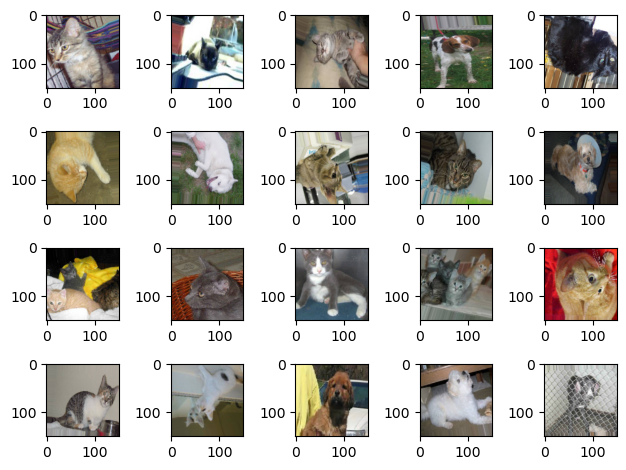

In [12]:
# ImageDataGenerator를 생성해서 사용해 보아요!

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_dir = 'C:/data/cat_dog_small/train'
validation_dir = 'C:/data/cat_dog_small/validation'

# ImageDataGenerator생성
train_datagen = ImageDataGenerator(rescale=1/255,
                                   rotation_range=20,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   vertical_flip=True,
                                   shear_range=0.1,
                                   fill_mode='nearest')
validation_datagen = ImageDataGenerator(rescale=1/255)

# ImageDataGenerator설정
train_generator = train_datagen.flow_from_directory(
    train_dir,    # target directory
    classes=['cats', 'dogs'],  # cats, dogs 순서로 label을 0, 1로 사용
    target_size=(150,150),     # Image에 대한 size 변경
    batch_size=20,       # 한번에 20개의 이미지에 대한 pixel 정보를 가져와요!
                         # label에 상관없이 가져와요!
    class_mode='binary'  # 이진분류이면 binary, 다중분류인경우 categorical
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,    # target directory
    classes=['cats', 'dogs'],  # cats, dogs 순서로 label을 0, 1로 사용
    target_size=(150,150),     # Image에 대한 size 변경
    batch_size=20,       # 한번에 20개의 이미지에 대한 pixel 정보를 가져와요!
                         # label에 상관없이 가져와요!
    class_mode='binary'  # 이진분류이면 binary, 다중분류인경우 categorical
)

for x_data, t_data in train_generator:
    print(f'x_data의 shape : {x_data.shape}')  # (20, 150,150,3)
    print(f't_data의 shape : {t_data.shape}')  # (20,)
    break;

# generator를 이용해서 20장의 이미지를 출력해보세요!(4행5열)
fig = plt.figure()
axs = []

for i in range(20):
    axs.append(fig.add_subplot(4,5,i+1))

for x_data, t_data in train_generator:
    # print(f'x_data의 shape : {x_data.shape}')  # (20, 150,150,3)
    for idx, img_data in enumerate(x_data):
        axs[idx].imshow(img_data)    
    print(t_data)
    break;

plt.tight_layout()
plt.show()

In [13]:
# Model 구성
# 파일이 생성되었으니 CNN을 이용해서 고양이와 멍멍이 이진분류 모델을
# 만들어보아요!

# 필요한 module import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Model 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import Activation, Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

# Model 구현
model = Sequential()

model.add(Conv2D(filters=32,
                kernel_size=(3,3),
                strides=(1,1),
                padding='SAME',
                activation='relu',
                input_shape=(150,150,3)))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64,
                kernel_size=(3,3),
                strides=(1,1),
                padding='SAME',
                activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=128,
                kernel_size=(3,3),
                strides=(1,1),
                padding='VALID',
                activation='relu'))

model.add(Conv2D(filters=256,
                kernel_size=(3,3),
                strides=(1,1),
                padding='VALID',
                activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=256,
                kernel_size=(3,3),
                strides=(1,1),
                padding='VALID',
                activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

# FC Layer ( Classifier )
model.add(Flatten())
model.add(Dropout(rate=0.5))

# Hidden Layer
model.add(Dense(units=128))
model.add(BatchNormalization())
model.add(Activation('relu'))

# output layer
model.add(Dense(units=1,
                activation='sigmoid'))

model.summary()

# Model 설정
model.compile(optimizer=RMSprop(learning_rate=1e-4),
             loss='binary_crossentropy',
             metrics=['accuracy'])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 150, 150, 32)      896       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 75, 75, 32)       0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 37, 37, 64)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 35, 35, 128)       73856     
                                                                 
 conv2d_8 (Conv2D)           (None, 33, 33, 256)      

In [ ]:
# 학습
history = model.fit(train_generator,
                   steps_per_epoch=100,
                   epochs=30,
                   validation_data=validation_generator,
                   validation_steps=50)
# 전체데이터를 이용한 학습 모델의 정확도는 대략 85% 정도되요!
# 일부데이터를 이용한 학습 모델의 정확도는 ?? 75% (증식 안했을때 )
# 일부데이터를 이용한 학습 모델의 정확도는 ?? 67% (증식 했을때 )

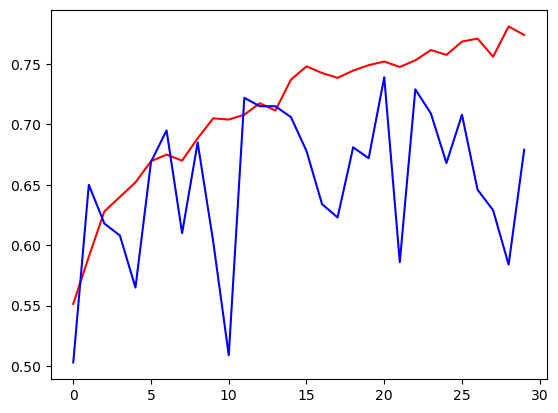

In [16]:
train_loss = history.history['accuracy']
val_loss = history.history['val_accuracy']

plt.plot(train_loss, color='r')
plt.plot(val_loss, color='b')
plt.show()

(150, 150, 3)


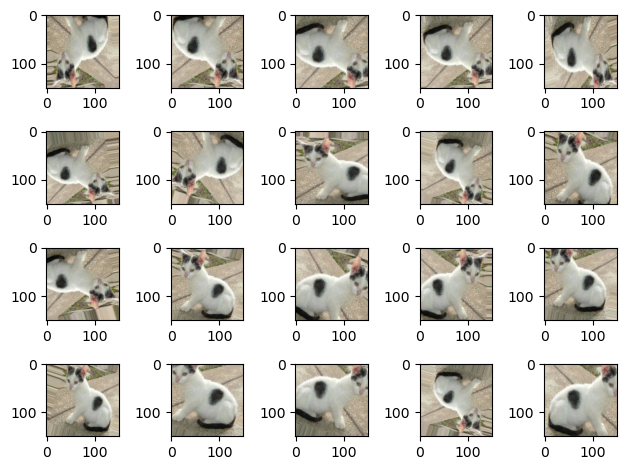

In [11]:
# 이미지 부족으로 인해
# 모델의 정확도가 많이 떨어졌어요 => overfitting때문에 그래요!
# 그래서 이미지 부족을 해결하기 위해 증식을 사용할꺼예요!
# Image Augmentation은 기존 이미지에 약간의 변형을 통해 새로운 이미지를 만들어
# 내는 방식을 의미해요. 
# 증식된 새로운 파일을 직접 만들어내는 방법도 있겠으나 이 방식은 너무 naive해요!
# ImageDataGenerator를 이용하면 편하게 증식도 할 수 있어요!
# 코드로 확인해보아요!
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 이미지 1장을 증식시켜보아요!
datagen = ImageDataGenerator(rotation_range=20,
                            width_shift_range=0.1,
                            height_shift_range=0.1,
                            zoom_range=0.2,
                            horizontal_flip=True,
                            vertical_flip=True,
                            shear_range=0.1,
                            fill_mode='nearest')
img = image.load_img('./cat_dog_small/train/cats/cat.3.jpg',
                    target_size=(150,150))
# print(type(img))
x = image.img_to_array(img)
print(x.shape)  # (150, 150, 3)  => (1, 150, 150, 3) 
x = x.reshape((1,) + x.shape)

# 이미지가 준비되었으니 ImageDataGenerator를 이용해서
# 증식된 이미지 20장을 추출해서 그림을 그려보아요!
fig = plt.figure()
axs = []

for i in range(20):
    axs.append(fig.add_subplot(4,5,i+1))

idx = 0
for batch in datagen.flow(x, batch_size=1):
    axs[idx].imshow(image.array_to_img(batch[0]))
    idx += 1
    if idx % 20 == 0:
        break

fig.tight_layout()
plt.show()